# Сжатие картинок с помощью SVD разложения
В этом задании нужно сделать сжатие изображения, сжатие с потерями. Для этого мы используем SVD разложение.

Примерный порядок действий:
1) Найти любую картинку,
2) Прочитать её с помощью библиотеки PIL
3) Преобразовать в numpy массив
4) Применить SVD к матрице - обязательно прочитайте справку по этой функции `np.linalg.svd`

**Примечание**: Цветная картинка представляет собой трёхканальное изображение RBG, поэтому напрямую SVD разложение применить не получится. Либо вы преобразуете изображение в одноканальное (градации серого), усредняя все три канала. Либо делаете SVD для всех трёх каналов в отдельности.

5) Далее оставляете небольшое количество сингулярных значений - 1, 2, 10, 30, 100. И выводите результат в виде получившейся картинки - чем больше сингулярных чисел, тем ближе приближённая матрица к исходной.

6) Сравните количество байт, необходимых для хранения исходной картинки и сжатой версии.

Ниже представлены основные функции и библиотеки, которые вам понадобятся.

Задание оформляете в виде блокнота jupyter. Особо понравившиеся картинки можно сохранить отдельно на диск, но мне удобнее чтобы они присутствовали в самом jupyter блокноте.

In [5]:
import PIL as pil
import numpy as np
from matplotlib import pyplot as plt
from IPython.display import display
import sys

from PIL import Image
import requests

response = requests.get("https://i.ytimg.com/vi/D7Dt0BRFO2w/maxresdefault.jpg", stream=True)
response.raw.decode_content = True
img = Image.open(response.raw)
#img = pil.Image.open('panda.jpg')
w, h = img.size
# img = img.resize((w//4, h//4)) # можно не делать .resize(())

# x = np.array(img, dtype=np.float32) # преобразование из PIL в numpy array
# U, S, V = np.linalg.svd(X, full_matrices=False) # разложение SVD
# # обратное преобразование из numpy array в PIL с сохранение изображения на диск
# Image.fromarray(np.asarray(Y_r, dtype=np.uint8)).save(f'{r}.png')

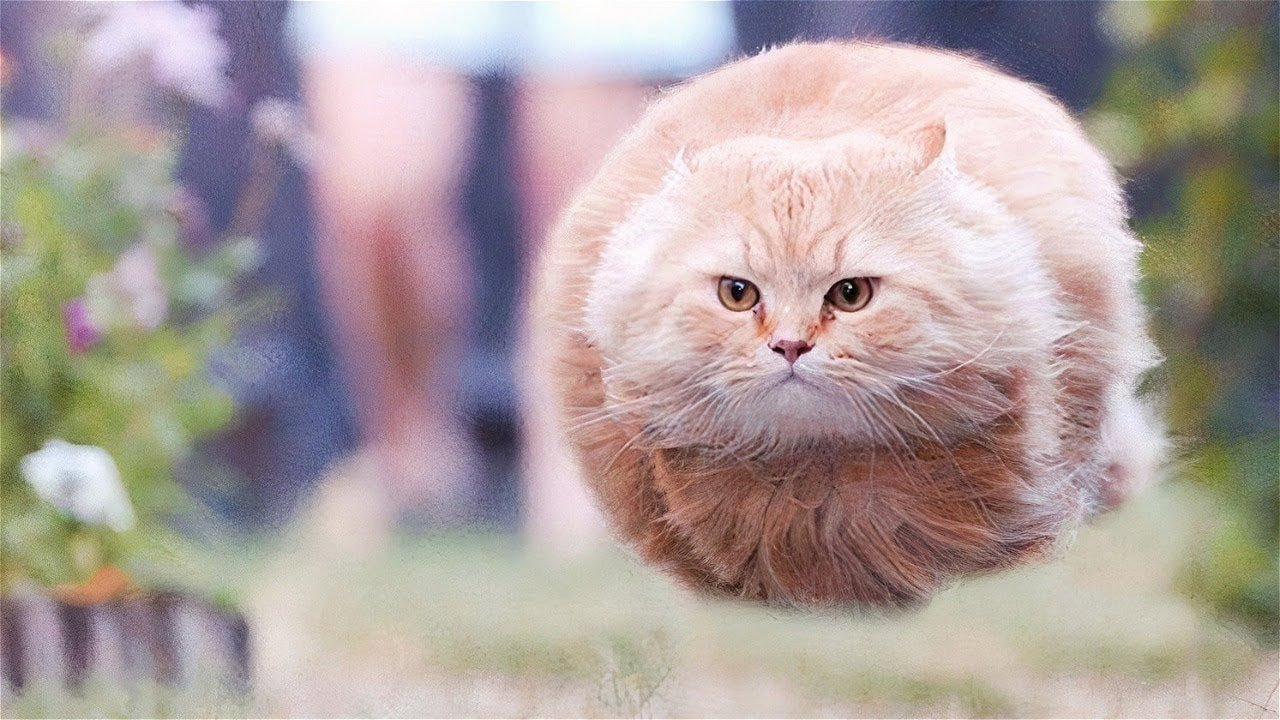

In [6]:
img

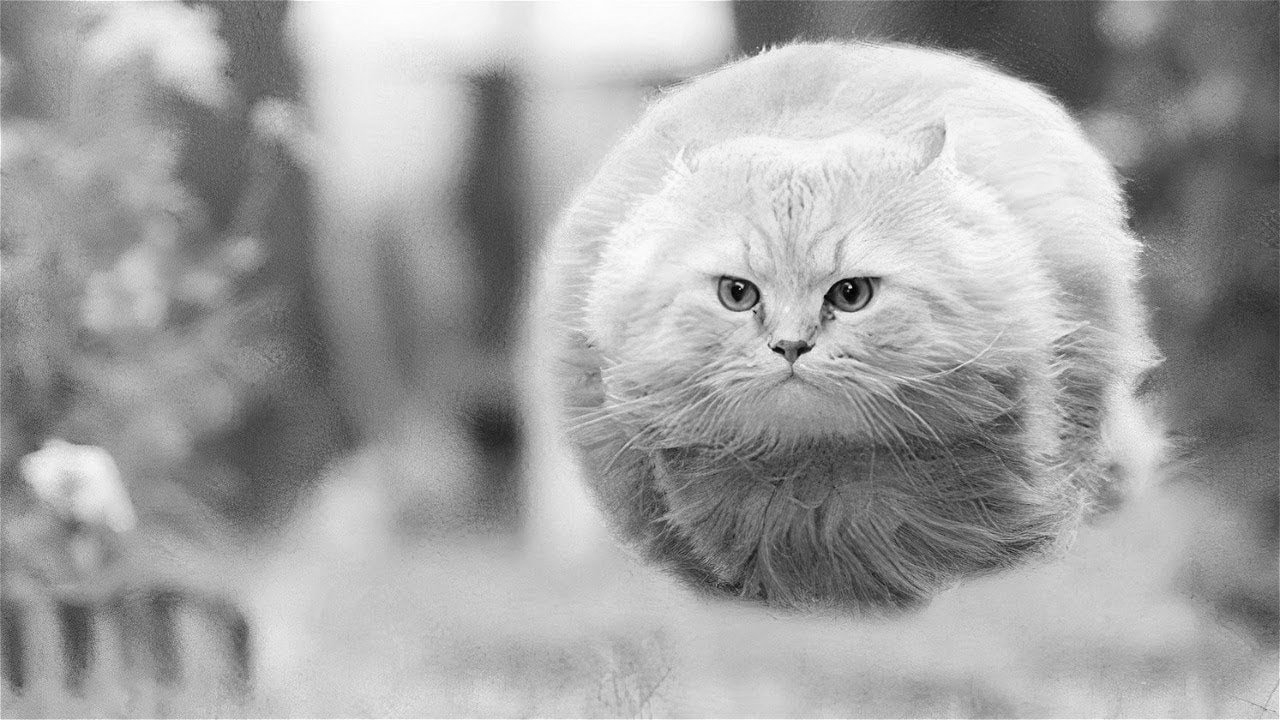

In [9]:
def rgb2gray(rgb):
    r, g, b = rgb[:,:,0], rgb[:,:,1], rgb[:,:,2]
    gray = 0.2989 * r + 0.5870 * g + 0.1140 * b

    return gray

def create_pic(U, S, V, singul):
    reconstim = np.matrix(U[:, :singul]) * np.diag(S[:singul]) * np.matrix(V[:singul, :])
    reconstim = pil.Image.fromarray(reconstim)
    reconstim = reconstim.convert("RGB")
    return reconstim


def Full_gray(url, n_singular = [10]):
    rez = []
    response = requests.get(url, stream=True)
    response.raw.decode_content = True
    img = Image.open(response.raw)
    w, h = img.size
    # img = img.resize((w//4, h//4))
    arr = np.array(img)
    N = min(np.shape(arr)[:1])
    arr_gray = rgb2gray(arr)
    U, S, V = np.linalg.svd(arr_gray)
    for i in n_singular + [N]:
        rez.append(create_pic(U, S, V, i))
    return rez

Full_gray("https://i.ytimg.com/vi/D7Dt0BRFO2w/maxresdefault.jpg", n_singular = [1, 2, 10, 30, 100])[-1]

In [11]:
print("Исходный файл:", sys.getsizeof('panda.jpg'), "\nСжатый до 100 синг.знач.: ", sys.getsizeof(Full_gray("https://i.ytimg.com/vi/D7Dt0BRFO2w/maxresdefault.jpg", n_singular = [1, 2, 10, 30, 100])[-1]), " В байтах")

Исходный файл: 58 
Сжатый до 100 синг.знач.:  48  В байтах


In [13]:
response = requests.get("https://i.ytimg.com/vi/D7Dt0BRFO2w/maxresdefault.jpg", stream=True)
response.raw.decode_content = True
img = Image.open(response.raw)
w, h = img.size
img = img.resize((w//4, h//4)) # можно не делать .resize(())

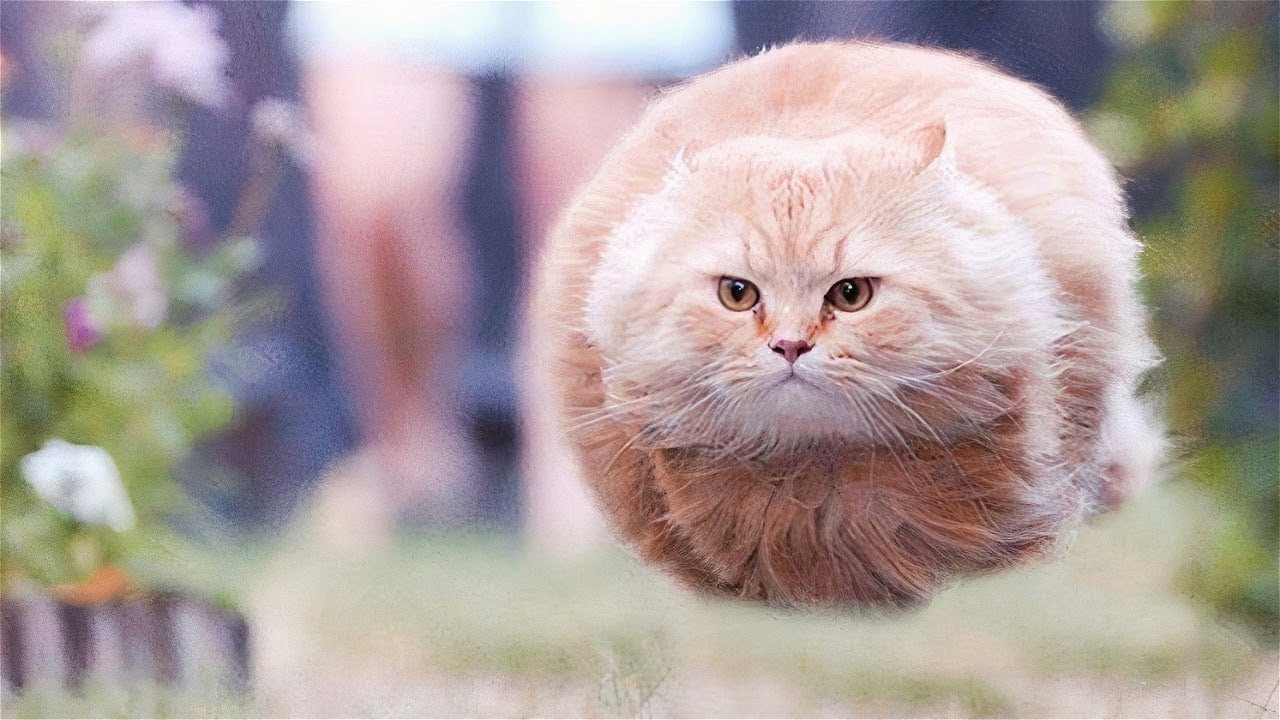

In [16]:
def rgb(rgb):
    r, g, b = rgb[:,:,0], rgb[:,:,1], rgb[:,:,2]
    return r, g, b

def create_pic_rgb(U_r, S_r, V_r, U_g, S_g, V_g, U_b, S_b, V_b, singul):
    reconstim_r = np.matrix(U_r[:, :singul]) * np.diag(S_r[:singul]) * np.matrix(V_r[:singul, :])
    reconstim_g = np.matrix(U_g[:, :singul]) * np.diag(S_g[:singul]) * np.matrix(V_g[:singul, :])
    reconstim_b = np.matrix(U_b[:, :singul]) * np.diag(S_b[:singul]) * np.matrix(V_b[:singul, :])
    reconstim = np.zeros((np.shape(reconstim_r)[0], np.shape(reconstim_r)[1], 3), dtype="uint8")
    reconstim[:, :, 0] = reconstim_r
    reconstim[:, :, 1] = reconstim_g
    reconstim[:, :, 2] = reconstim_b
    reconstim.astype("int")
    reconstim = reconstim.clip(min=0, max=255)
    reconstim = pil.Image.fromarray(reconstim)
    reconstim = reconstim.convert("RGB")
    return reconstim


def Full_gray(url, n_singular = [10]):
    rez = []
    response = requests.get(url, stream=True)
    response.raw.decode_content = True
    img = Image.open(response.raw)
    w, h = img.size
    # img = img.resize((w//4, h//4))
    arr = np.array(img)
    N = min(np.shape(arr)[:1])
    r, g, b = rgb(arr)
    U_r, S_r, V_r = np.linalg.svd(r)
    U_g, S_g, V_g = np.linalg.svd(g)
    U_b, S_b, V_b = np.linalg.svd(b)
    for i in n_singular + [N]:
        rez.append(create_pic_rgb(U_r, S_r, V_r, U_g, S_g, V_g, U_b, S_b, V_b, i))
    return rez

Full_gray("https://i.ytimg.com/vi/D7Dt0BRFO2w/maxresdefault.jpg", n_singular = [1, 2, 10, 30, 100, 130])[-1]

In [18]:
data = [12, 31, 2, 312, 1, 3, 23, 1, 2]

def srez(data, dolya = 0.4):
    d = np.array(data)
    d.sort()
    d = d[::-1]
    N = len(d)
    print(int (N * dolya))
    mes = d[int (N * dolya)]

    E = np.mean(d[int (N * dolya):])

    for i in range(0, N):
        if data[i] > mes:
            data[i] = E

    return data

srez(data)

3


[12, 3.5, 2, 3.5, 1, 3, 3.5, 1, 2]

In [ ]:
#я только заменил получение картинки из файла на из ссылки
#дальше ничего нет, но два года назад мы такое задание на вашем курсе делали (введение в специальность)